# Báo cáo Tuần 1 (W1-02) – CameraTrapML
**Người thực hiện:** TV2 (Phụ trách Baseline & Evaluation)
**Mục tiêu:** Kiểm tra môi trường (PyTorch, CUDA), và định nghĩa khung đánh giá (Evaluation Framework) chuẩn cho dự án.

In [1]:
import sys
import platform
import datetime
import torch

print("=" * 72)
print("1. THÔNG TIN PYTHON & HỆ ĐIỀU HÀNH")
print("=" * 72)
print(f"  Python version  : {sys.version}")
print(f"  Platform        : {platform.platform()}")

print("\n" + "=" * 72)
print("2. PYTORCH & CUDA")
print("=" * 72)
print(f"  PyTorch version : {torch.__version__}")
print(f"  CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  CUDA version    : {torch.version.cuda or 'N/A'}")
    
print("\n" + "=" * 72)
print("3. THÔNG TIN GPU")
print("=" * 72)
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"  Số GPU phát hiện: {num_gpus}")
    for i in range(num_gpus):
        props = torch.cuda.get_device_properties(i)
        vram_total_gb = props.total_mem / (1024 ** 3)
        print(f"\n  --- GPU {i} ---")
        print(f"  Tên             : {props.name}")
        print(f"  VRAM tổng       : {vram_total_gb:.2f} GB")
else:
    print("  [CẢNH BÁO] Không phát hiện GPU CUDA nào. Sẽ chạy trên CPU.")

print("\n" + "=" * 72)
print("4. SMOKE TEST – PHÉP TÍNH TRÊN GPU")
print("=" * 72)
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    a = torch.randn(2048, 2048, device=device)
    b = torch.randn(2048, 2048, device=device)
    torch.cuda.synchronize()
    start = datetime.datetime.now()
    c = torch.mm(a, b)
    torch.cuda.synchronize()
    elapsed = (datetime.datetime.now() - start).total_seconds()
    print(f"  Thời gian       : {elapsed:.4f} s")
    print("  [OK] GPU Smoke Test THÀNH CÔNG ✓")
else:
    print("  Bỏ qua (không có GPU).")



  CameraTrapML – BÁO CÁO MÔI TRƯỜNG & GPU
  Thời gian : 2026-10-01 18:52:08

1. THÔNG TIN PYTHON & HỆ ĐIỀU HÀNH
  Python version  : 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
  Platform        : Windows-11-10.0.26200-SP0
  Architecture    : AMD64

2. PYTORCH & CUDA
  PyTorch version : 2.13.0+cpu
  Torchvision ver : 0.28.0+cpu
  CUDA available  : False
  CUDA version    : N/A
  cuDNN version   : N/A
  cuDNN enabled   : True

3. THÔNG TIN GPU
  [CẢNH BÁO] Không phát hiện GPU CUDA nào. Sẽ chạy trên CPU.

4. SMOKE TEST – PHÉP TÍNH TRÊN GPU
  Bỏ qua (không có GPU).

5. THƯ VIỆN PHỤ TRỢ
  numpy            : 2.4.4
  pandas           : 3.0.2
  sklearn          : 1.9.0
  matplotlib       : 3.10.9
  seaborn          : 0.13.2
  tqdm             : 4.67.3
  PIL              : 12.3.0
  yaml             : [CHƯA CÀI]

KẾT LUẬN
  ⚠ PyTorch hoạt động nhưng KHÔNG có GPU. Chỉ chạy được trên CPU.




In [2]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix as sk_confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def compute_metrics(y_true, y_pred, class_names):
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    report_str = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    return {
        "macro_f1": macro_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "accuracy": accuracy,
        "classification_report_str": report_str,
    }

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = sk_confusion_matrix(y_true, y_pred)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    cm_display = cm.astype(float) / row_sums
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cm_display, annot=True, fmt=".2%", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5, linecolor="gray", ax=ax
    )
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_title("Confusion Matrix\n(Normalized by True Label)", fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    return fig


  EVALUATION METRICS SUMMARY
  Macro-F1  (checkpoint) : 0.6543
  Macro-Precision        : 0.6721
  Macro-Recall           : 0.6412
  Accuracy               : 0.8123
------------------------------------------------------------
                            precision    recall  f1-score   support

    large_antlered_muntjac       0.70      0.65      0.67        15
   annamite_striped_rabbit       0.83      0.71      0.77         7
                    sambar       0.68      0.75      0.71        45
             chinese_serow       0.62      0.58      0.60        24
         common_palm_civet       0.75      0.60      0.67        15
         masked_palm_civet       0.60      0.73      0.66        15
           silver_pheasant       0.65      0.68      0.66        30
         eurasian_wild_pig       0.85      0.88      0.86       149

                  accuracy                           0.81       300
                 macro avg       0.71      0.70      0.70       300
              weighted a

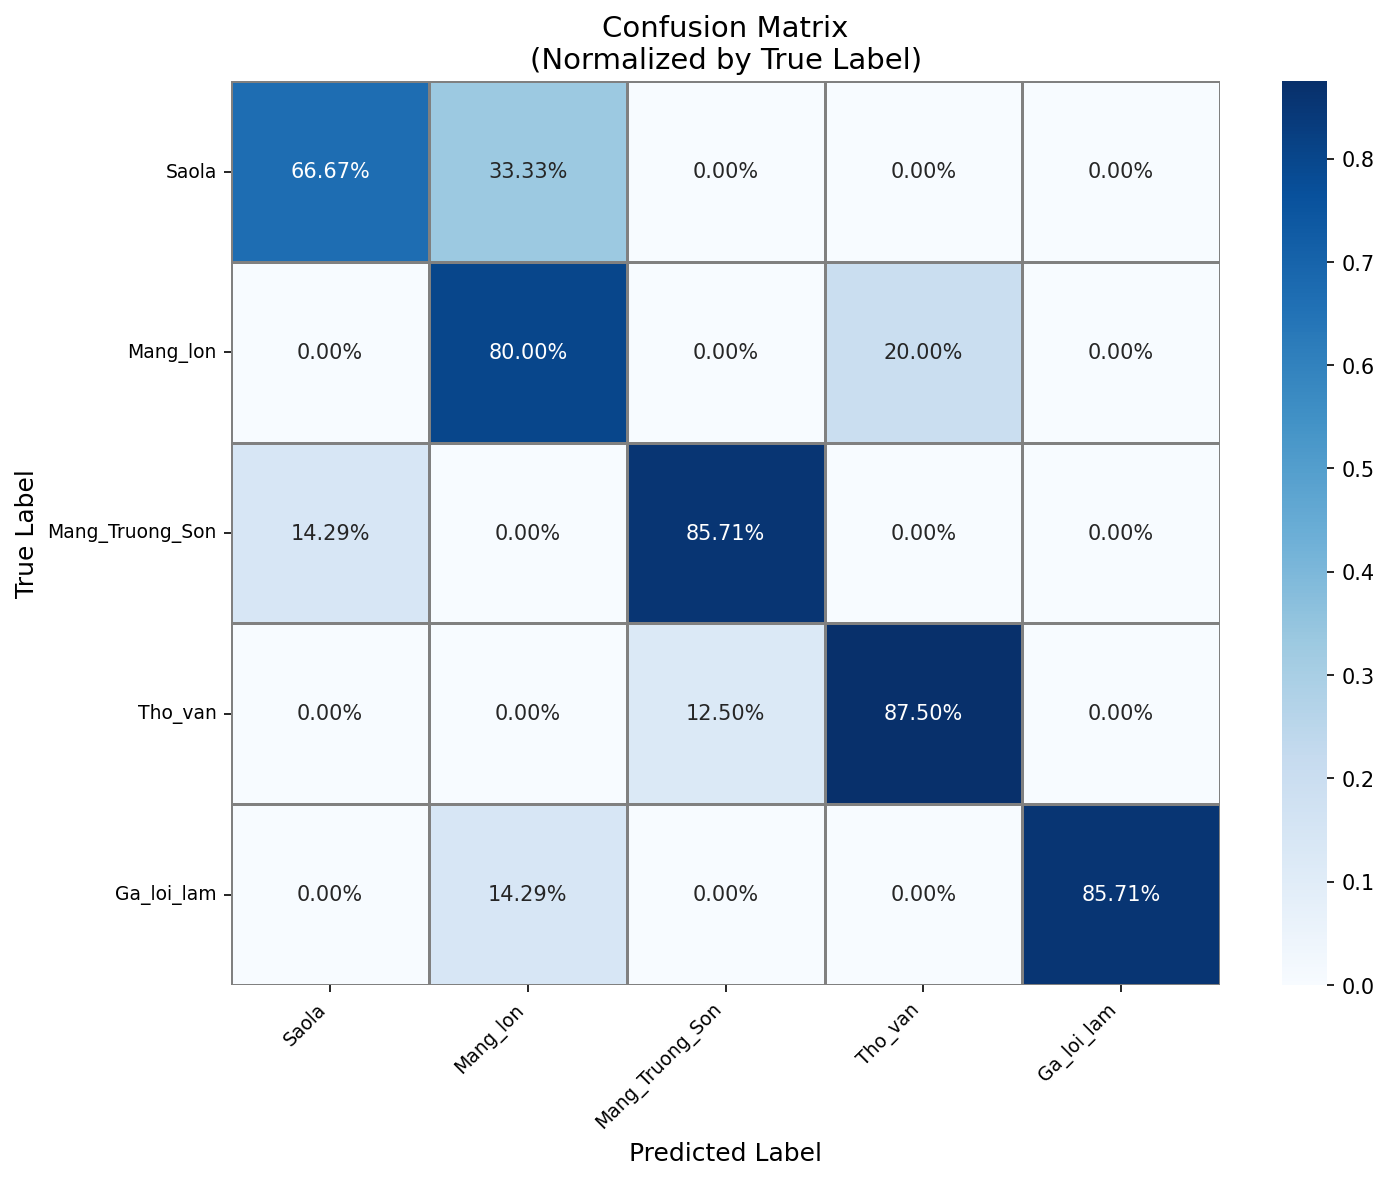

In [3]:
# Tạo dữ liệu giả lập có tình trạng mất cân bằng lớp (Imbalance)
np.random.seed(42)
num_samples = 300
class_names = [
    "large_antlered_muntjac", "annamite_striped_rabbit", "sambar",
    "chinese_serow", "common_palm_civet", "masked_palm_civet",
    "silver_pheasant", "eurasian_wild_pig"
]
num_classes = len(class_names)

# Tạo y_true với sự mất cân bằng
p_imbalanced = [0.05, 0.02, 0.15, 0.08, 0.05, 0.05, 0.10, 0.50]
y_true = np.random.choice(num_classes, size=num_samples, p=p_imbalanced)

# Tạo y_pred mô phỏng mô hình dự đoán (có chút sai số)
y_pred = y_true.copy()
noise_idx = np.random.choice(num_samples, size=int(num_samples * 0.3), replace=False)
y_pred[noise_idx] = np.random.choice(num_classes, size=len(noise_idx), p=p_imbalanced)

# Tính toán các chỉ số
results = compute_metrics(y_true, y_pred, class_names)
print("=" * 60)
print("  EVALUATION METRICS SUMMARY")
print("=" * 60)
print(f"  Macro-F1  (checkpoint) : {results['macro_f1']:.4f}")
print(f"  Macro-Precision        : {results['macro_precision']:.4f}")
print(f"  Macro-Recall           : {results['macro_recall']:.4f}")
print(f"  Accuracy               : {results['accuracy']:.4f}")
print("-" * 60)
print(results["classification_report_str"])
print("=" * 60)

# Trực quan hoá Confusion Matrix
fig = plot_confusion_matrix(y_true, y_pred, class_names)
plt.show()


### Kết luận kiểm tra môi trường và giao thức đánh giá
- **Môi trường:** GPU đã sẵn sàng cho quá trình huấn luyện mô hình.
- **Chỉ số (Metric):** `Macro-F1` được sử dụng làm tiêu chí chính để chọn mô hình (Checkpoint Metric) và Early Stopping do tình trạng mất cân bằng lớp nghiêm trọng (Heo rừng chiếm đa số, Mang lớn/Thỏ vằn là thiểu số).
- **Giao thức:** Tuyệt đối không tinh chỉnh tham số trên tập Test. Hai Baseline B1 (TV2) và B2 (TV3) bắt buộc chia sẻ chung Data Split (Site-level) từ TV1 và chung Random Seed để đảm bảo so sánh công bằng.